<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/Airbnb_Berlin_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install missingno
# !pip install geopy
# !pip install xgboost

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')

# Feature Selection

In [5]:
df_Feature_Selection = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Selection.pkl')
df_Feature_Selection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Accuracy Rating               23536 non-null  float64       
 1   Bathrooms                     23536 non-null  float64       
 2   Checkin Rating                23536 non-null  float64       
 3   Cleanliness Rating            23536 non-null  float64       
 4   Communication Rating          23536 non-null  float64       
 5   Latitude                      23536 non-null  float64       
 6   Location Rating               23536 non-null  float64       
 7   Longitude                     23536 non-null  float64       
 8   Overall Rating                23536 non-null  float64       
 9   Price                         23536 non-null  float64       
 10  Value Rating                  23536 non-null  float64       
 11  Comments                    

In [6]:
df_Feature_Selection['Distance From Center Reduced']

,Distance From Center Reduced
0,km_4
1,km_2
2,km_4
3,km_2
4,km_4
...,...
23531,km_25
23532,km_25
23533,km_4
23534,km_25


In [7]:
df = df_Feature_Selection.copy()

In [8]:
df = df.drop(columns=['Host Since','Host Since Year', 'Postal Code', 'Property Type', 'Comments','neighbourhood',
                      'Longitude', 'Latitude'], inplace=False)

# ,
#                       'Distance From Center', 'Longitude', 'Latitude'

In [9]:
df = df[(df['Price'] <= 600) & (df['Price'] > 0)]

## One-Hot Enciding and Label Encoding

In [10]:
from sklearn.preprocessing import OrdinalEncoder

df_object =  df.select_dtypes(include = ['object','category']).columns
for col in df_object:
  ord_enc = OrdinalEncoder()
  df[[col]] = ord_enc.fit_transform(df[[col]]).astype('int')

In [11]:
df.head(2)

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Location Rating,Overall Rating,Price,Value Rating,Host Response Time,Is Superhost,Neighborhood Group,Is Exact Location,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Distance From Center Reduced,Host Since From Now
0,10.0,1.0,10.0,10.0,10.0,9.0,100.0,17.0,10.0,2,False,6,True,1,False,2.0,1.0,1.0,1.0,2.000000,7.0,0,0,5.1,7,17
1,9.0,1.0,9.0,9.0,9.0,10.0,92.0,90.0,9.0,2,False,6,True,0,False,4.0,1.0,2.0,2.0,1.727273,144.0,0,0,3.7,5,17


## Multivariable Analysis

In [12]:
#Creating Variables dataframeS
varSel = pd.DataFrame({'Variable': df.columns.drop('Price')})
varSel

,Variable
0,Accuracy Rating
1,Bathrooms
2,Checkin Rating
3,Cleanliness Rating
4,Communication Rating
5,Location Rating
6,Overall Rating
7,Value Rating
8,Host Response Time
9,Is Superhost


In [13]:
df.to_csv('/content/drive/My Drive/Airbnb/df_Feature_Selection.csv')

In [14]:
nm = df.columns.drop('Price')
nm = nm.append(pd.Index(['Price']))
nm

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Location Rating', 'Overall Rating',
       'Value Rating', 'Host Response Time', 'Is Superhost',
       'Neighborhood Group', 'Is Exact Location', 'Room Type',
       'Instant Bookable', 'Accomodates', 'Bedrooms', 'Beds',
       'Guests Included', 'Min Nights', 'Reviews', 'Property Type Reduced',
       'Postal Code Reduced', 'Distance From Center',
       'Distance From Center Reduced', 'Host Since From Now', 'Price'],
      dtype='object')

In [15]:
df2 = df[nm].copy()

In [16]:
df2 = df2.dropna()
X = df.drop(columns='Price', inplace=False)
y = df['Price']

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge


### Variable Selection using LASSO (L1 penalization)

In [18]:
lassomod = Lasso(alpha=0.01).fit(X, y)
model = SelectFromModel(lassomod, prefit=True)
# print(f"get_support: {model.get_support()}")
# print(f"coef: {lassomod.coef_}")
varSel['Lasso'] = model.get_support().astype('int64')

### Variable Selection using Ridge

In [19]:
ridge = Ridge(alpha=5).fit(X, y)
model = SelectFromModel(ridge, prefit=True)
# print(f"get_support: {model.get_support()}")
# print(f"coef: {ridge.coef_}")
varSel['Ridge'] = model.get_support().astype('int64')

In [20]:
alpha_values = np.logspace(-1, 1, 10)  # 10 values between 10^-4 and 10^4

In [21]:
alpha_values

array([ 0.1       ,  0.16681005,  0.27825594,  0.46415888,  0.77426368,
        1.29154967,  2.15443469,  3.59381366,  5.9948425 , 10.        ])

In [22]:
from sklearn.linear_model import RidgeCV

# RidgeCV automatically finds the best alpha
ridge_cv = RidgeCV(alphas=alpha_values, store_cv_values=True)
ridge_cv.fit(X, y)

# Print the best alpha
print(f"Best alpha: {ridge_cv.alpha_}")


Best alpha: 10.0


### Variable Selection using Gradient Boosting classification

In [23]:
gbmod = GradientBoostingRegressor().fit(X, y)
model = SelectFromModel(gbmod , prefit=True)
# print(f"get_support: {model.get_support()}")
# print(f"coef: {gbmod.coef_}")
varSel['GradientBoost'] = model.get_support().astype('int64')

### Variable Selection using Random Forest

In [24]:
rfmod = RandomForestRegressor().fit(X, y)
model = SelectFromModel(rfmod, prefit=True)
# print(f"get_support: {model.get_support()}")
# print(f"coef: {rfmod.coef_}")
varSel['RandomForest'] = model.get_support().astype('int64')

### Variable Selection using SVM classification

Commented out because it taked long time and never finish

In [25]:
# from sklearn.svm import LinearSVC, SVR
# from sklearn.feature_selection import SelectFromModel

# # svmmod = LinearSVC(C=0.01, penalty="l1",dual=False).fit(X, y)
# svmmod = SVR(kernel='linear').fit(X, y)
# model = SelectFromModel(svmmod, prefit=True)
# model.get_support()
# varSel['SVM'] = model.get_support().astype('int64')

### Summarization and Selection of Variables

In [26]:
varSel['Sum'] = varSel[['Lasso', 'Ridge', 'GradientBoost','RandomForest']].sum(axis=1)
varSel

,Variable,Lasso,Ridge,GradientBoost,RandomForest,Sum
0,Accuracy Rating,1,0,0,0,1
1,Bathrooms,0,0,0,0,0
2,Checkin Rating,0,0,0,0,0
3,Cleanliness Rating,1,1,0,0,2
4,Communication Rating,1,0,0,0,1
5,Location Rating,1,1,0,0,2
6,Overall Rating,1,0,0,0,1
7,Value Rating,1,1,0,0,2
8,Host Response Time,1,0,0,0,1
9,Is Superhost,1,0,0,0,1


In [27]:
varSel.to_csv('/content/drive/My Drive/Airbnb/Feature_Selection_models.csv')

In [28]:
varSel.shape

(25, 6)

In [29]:
varSel[['Variable', 'Sum']].sort_values(by='Sum', ascending=False)

,Variable,Sum
12,Room Type,4
17,Guests Included,4
15,Bedrooms,4
14,Accomodates,4
20,Property Type Reduced,3
7,Value Rating,2
5,Location Rating,2
19,Reviews,2
3,Cleanliness Rating,2
24,Host Since From Now,2


In [30]:
varSel[varSel['Sum'] >=2].shape

(12, 6)

### Creating DataFrame with most valuable variables

In [31]:
selected_vars = varSel[varSel['Sum'] >=2]['Variable']

In [32]:
# df_model = df.loc[:,selected_vars]
# df_model['Price'] = df['Price'].copy()
# # Output the result to verify
# df_model.info()

## Multivariable Analysis

In [33]:
from sklearn.svm import LinearSVC

# Fit models and determine if a feature is selected (1) or not (0)
lasso = Lasso(alpha=5).fit(X, y)
lasso_selected = (np.abs(lasso.coef_) > 0).astype(int)

# Fit Ridge model
ridge = Ridge(alpha=5).fit(X, y)
ridge_selected = (np.abs(ridge.coef_) > 0).astype(int)

gb = GradientBoostingRegressor().fit(X, y)
gb_selected = (gb.feature_importances_ > 0).astype(int)

rf = RandomForestRegressor().fit(X, y)
rf_selected = (rf.feature_importances_ > 0).astype(int)

# Create a DataFrame to store results
selection_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso': lasso_selected,
    'GradientBoost': gb_selected,
    'RandomForest': rf_selected,
    'Ridge': ridge_selected
})

# Sum the number of selections for each feature
selection_df['Sum'] = selection_df[['Lasso', 'GradientBoost', 'RandomForest','Ridge']].sum(axis=1)

# Output the results
selection_df

,Feature,Lasso,GradientBoost,RandomForest,Ridge,Sum
0,Accuracy Rating,0,1,1,1,3
1,Bathrooms,0,0,0,0,0
2,Checkin Rating,0,1,1,1,3
3,Cleanliness Rating,0,1,1,1,3
4,Communication Rating,0,1,1,1,3
5,Location Rating,0,1,1,1,3
6,Overall Rating,1,1,1,1,4
7,Value Rating,0,1,1,1,3
8,Host Response Time,1,1,1,1,4
9,Is Superhost,0,1,1,1,3


In [34]:
selection_df.to_csv('/content/selection_variable_modele.csv')

In [35]:
selection_df.shape

(25, 6)

In [36]:
selection_df[['Feature', 'Sum']].sort_values(by='Sum', ascending=False)

,Feature,Sum
8,Host Response Time,4
6,Overall Rating,4
19,Reviews,4
20,Property Type Reduced,4
22,Distance From Center,4
14,Accomodates,4
15,Bedrooms,4
16,Beds,4
12,Room Type,4
17,Guests Included,4


In [37]:
selection_df[selection_df['Sum'] >= 3].shape

(22, 6)

In [38]:
#Selecting variables with a sum of selections >= 4
selected_variables = selection_df[selection_df['Sum'] >= 3]['Feature']
selected_variables

,Feature
0,Accuracy Rating
2,Checkin Rating
3,Cleanliness Rating
4,Communication Rating
5,Location Rating
6,Overall Rating
7,Value Rating
8,Host Response Time
9,Is Superhost
10,Neighborhood Group


### Creating DataFrame with most valuable variables

In [39]:
df_model = df.loc[:,selected_variables]
df_model['Price'] = df['Price'].copy()

# Output the result to verify
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        23460 non-null  float64
 1   Checkin Rating         23460 non-null  float64
 2   Cleanliness Rating     23460 non-null  float64
 3   Communication Rating   23460 non-null  float64
 4   Location Rating        23460 non-null  float64
 5   Overall Rating         23460 non-null  float64
 6   Value Rating           23460 non-null  float64
 7   Host Response Time     23460 non-null  int64  
 8   Is Superhost           23460 non-null  bool   
 9   Neighborhood Group     23460 non-null  int64  
 10  Is Exact Location      23460 non-null  bool   
 11  Room Type              23460 non-null  int64  
 12  Accomodates            23460 non-null  float64
 13  Bedrooms               23460 non-null  float64
 14  Beds                   23460 non-null  float64
 15  Guests 

## Store state

In [40]:
selection_df.to_pickle("/content/drive/My Drive/Airbnb/feature_selection_df.pkl")
df_model.to_pickle("/content/drive/My Drive/Airbnb/df_Model_Selection.pkl")

# Model Selection and Fine Tuning

## Metrics

In [41]:
df_Model_Selection = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Model_Selection.pkl')
df_Model_Selection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        23460 non-null  float64
 1   Checkin Rating         23460 non-null  float64
 2   Cleanliness Rating     23460 non-null  float64
 3   Communication Rating   23460 non-null  float64
 4   Location Rating        23460 non-null  float64
 5   Overall Rating         23460 non-null  float64
 6   Value Rating           23460 non-null  float64
 7   Host Response Time     23460 non-null  int64  
 8   Is Superhost           23460 non-null  bool   
 9   Neighborhood Group     23460 non-null  int64  
 10  Is Exact Location      23460 non-null  bool   
 11  Room Type              23460 non-null  int64  
 12  Accomodates            23460 non-null  float64
 13  Bedrooms               23460 non-null  float64
 14  Beds                   23460 non-null  float64
 15  Guests 

In [42]:
df = df_Model_Selection.copy()
df = df[(df['Price'] <= 600) & (df['Price'] > 0)]

We reached this stage with only the most important feature bases on 3 out of 4 models (Review Feature Selection stage )

In [43]:
df.head()

,Accuracy Rating,Checkin Rating,Cleanliness Rating,Communication Rating,Location Rating,Overall Rating,Value Rating,Host Response Time,Is Superhost,Neighborhood Group,Is Exact Location,Room Type,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Host Since From Now,Price
0,10.0,10.0,10.0,10.0,9.0,100.0,10.0,2,False,6,True,1,2.000000,1.0,1.0,1.0,2.000000,7.0,0,0,5.1,17,17.0
1,9.0,9.0,9.0,9.0,10.0,92.0,9.0,2,False,6,True,0,4.000000,1.0,2.0,2.0,1.727273,144.0,0,0,3.7,17,90.0
2,10.0,10.0,10.0,10.0,10.0,96.0,10.0,4,True,6,True,1,2.000000,1.0,2.0,1.0,2.000000,229.0,0,0,4.6,16,33.0
3,10.0,10.0,10.0,10.0,10.0,100.0,10.0,2,False,6,False,0,3.636364,4.0,7.0,5.0,6.000000,6.0,0,0,3.5,16,180.0
4,10.0,9.0,10.0,10.0,9.0,93.0,9.0,2,False,6,True,0,1.000000,0.0,1.0,1.0,2.454545,23.0,0,0,5.0,16,70.0


In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accuracy Rating,23460.0,9.659614,0.682676,2.0,9.454545,10.000000,10.0,10.0
Checkin Rating,23460.0,9.709238,0.645831,2.0,9.636364,10.000000,10.0,10.0
Cleanliness Rating,23460.0,9.319216,0.949321,2.0,9.000000,9.636364,10.0,10.0
Communication Rating,23460.0,9.732330,0.626641,2.0,9.818182,10.000000,10.0,10.0
Location Rating,23460.0,9.531822,0.692451,2.0,9.000000,10.000000,10.0,10.0
Overall Rating,23460.0,94.593614,6.968951,20.0,92.727273,96.363636,100.0,100.0
Value Rating,23460.0,9.399849,0.775066,2.0,9.000000,9.636364,10.0,10.0
Host Response Time,23460.0,2.208483,1.332796,0.0,1.000000,2.000000,4.0,4.0
Neighborhood Group,23460.0,4.130264,2.939809,0.0,1.000000,4.000000,6.0,11.0
Room Type,23460.0,0.523444,0.525334,0.0,0.000000,1.000000,1.0,2.0


In [45]:
df.corr()

,Accuracy Rating,Checkin Rating,Cleanliness Rating,Communication Rating,Location Rating,Overall Rating,Value Rating,Host Response Time,Is Superhost,Neighborhood Group,Is Exact Location,Room Type,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Host Since From Now,Price
Accuracy Rating,1.000000,0.494658,0.520012,0.527813,0.374249,0.658492,0.592437,0.054185,0.158737,0.012897,0.021651,-0.026092,-0.006472,-0.002469,-0.060814,-0.004446,0.060590,0.076515,-0.008278,-0.019713,-0.013128,0.034186,0.025940
Checkin Rating,0.494658,1.000000,0.377434,0.617458,0.318516,0.508561,0.439422,0.070801,0.136202,0.017329,0.032987,-0.001975,-0.002863,0.018106,-0.012712,0.016051,0.025975,0.071005,0.018610,-0.013415,0.013583,0.024229,0.030924
Cleanliness Rating,0.520012,0.377434,1.000000,0.403526,0.299939,0.669369,0.525932,0.113654,0.192065,0.026066,0.011969,-0.059652,0.005231,0.030714,-0.005705,0.030603,0.011751,0.092094,0.044184,-0.015248,0.015729,0.040809,0.112347
Communication Rating,0.527813,0.617458,0.403526,1.000000,0.343720,0.576533,0.484296,0.058162,0.137632,0.016944,0.017687,-0.011796,-0.003548,0.008673,-0.032088,0.004375,0.030352,0.056386,-0.008045,-0.012679,-0.005736,0.041977,0.022504
Location Rating,0.374249,0.318516,0.299939,0.343720,1.000000,0.411841,0.415568,0.082373,0.104812,-0.065141,0.005391,-0.031592,0.000873,-0.009759,-0.054031,-0.009346,0.042884,0.073756,-0.040467,-0.117333,-0.187584,0.031001,0.083622
Overall Rating,0.658492,0.508561,0.669369,0.576533,0.411841,1.000000,0.681791,0.023671,0.155160,0.014339,0.007996,-0.011572,-0.030483,0.006682,-0.070626,-0.018160,0.063386,-0.001600,0.000699,-0.015326,-0.013084,0.020665,0.051339
Value Rating,0.592437,0.439422,0.525932,0.484296,0.415568,0.681791,1.000000,-0.003981,0.127767,0.023281,0.002800,0.073251,-0.078673,-0.022460,-0.094301,-0.051600,0.068492,0.016529,-0.023754,0.003883,0.009349,0.009589,-0.069281
Host Response Time,0.054185,0.070801,0.113654,0.058162,0.082373,0.023671,-0.003981,1.000000,0.364287,0.007908,0.047358,-0.050116,0.122286,0.050097,0.157187,0.149647,-0.115408,0.363463,0.156290,-0.043496,0.061375,-0.043366,0.159898
Is Superhost,0.158737,0.136202,0.192065,0.137632,0.104812,0.155160,0.127767,0.364287,1.000000,0.013718,0.039130,-0.006998,0.034289,0.032257,0.035140,0.084895,-0.060239,0.355657,0.083164,-0.035393,0.014861,0.050029,0.083564
Neighborhood Group,0.012897,0.017329,0.026066,0.016944,-0.065141,0.014339,0.023281,0.007908,0.013718,1.000000,0.024568,-0.018953,0.014088,0.035154,0.036813,0.003398,0.012248,-0.008676,0.040586,0.143318,0.300516,-0.011890,-0.036915


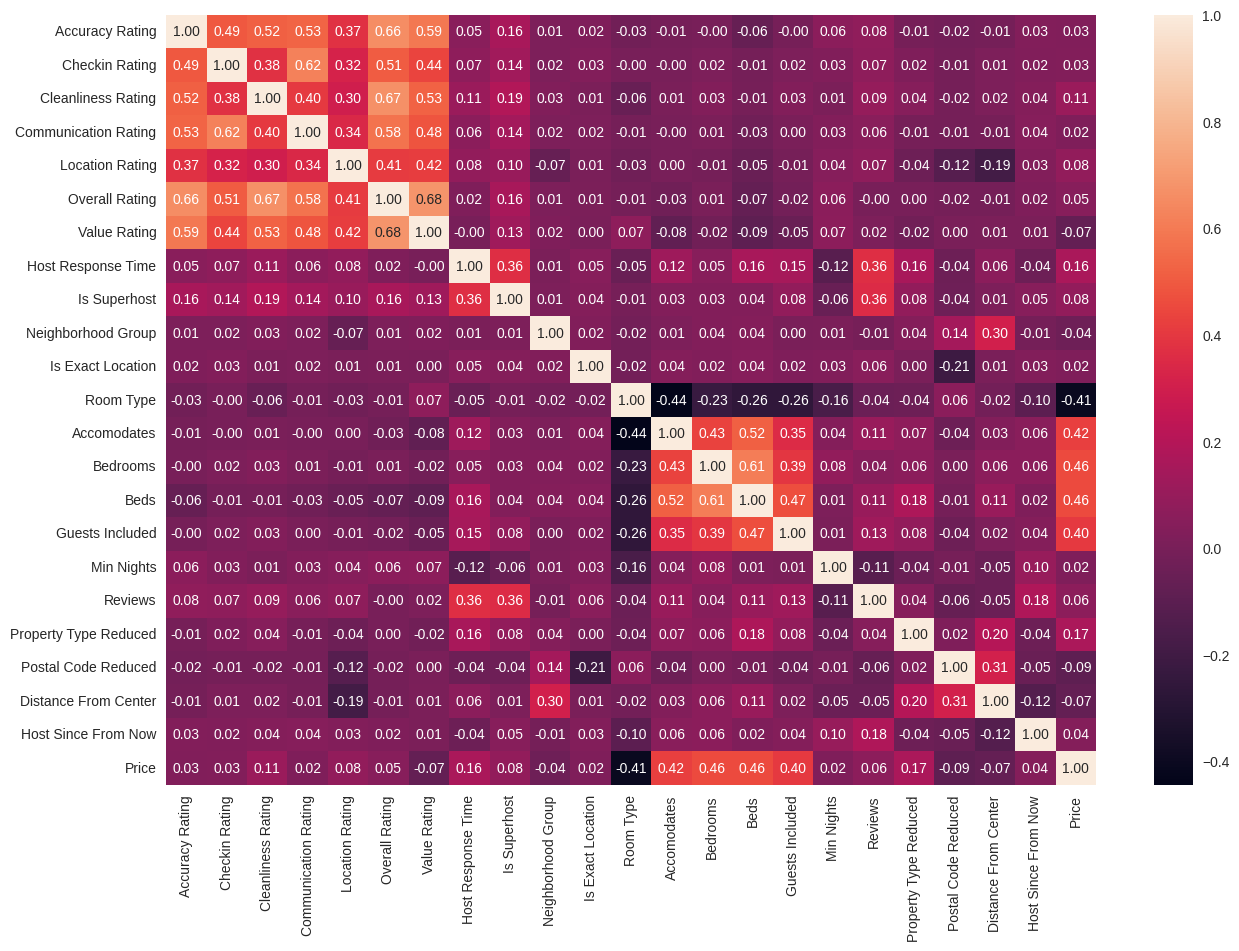

In [46]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", annot_kws={"size":10})
plt.show()

## Create and Train the Model

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import sklearn.metrics as metrics

In [48]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Price', inplace=False)
y = df['Price']

# Split into train+val and test sets (80% train+val, 20% test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split train+val into train and val sets (75% train, 25% val from the train+val set)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

## Regression Models

In [96]:
models_list = pd.DataFrame(columns= ['model', 'MAE', 'MSE', 'RMSE', 'RMSLE', 'R²'])
models_list.style.set_properties(subset=['model'], **{'text-align': 'left'})

,model,MAE,MSE,RMSE,RMSLE,R²


In [50]:
def regressionMetrics(y, y_pred):
    res = {
          'MAE': metrics.mean_absolute_error(y, y_pred),
          'MSE': metrics.mean_squared_error(y, y_pred),
          'RMSE': np.sqrt(metrics.mean_squared_error(y, y_pred)),
          'RMSLE': np.sqrt(metrics.mean_squared_log_error(np.abs(y), np.abs(y_pred))),
          'R²': metrics.r2_score(y, y_pred)
          }
    # # Calculate RMSLE using absolute values to avoid negative issues
    # res['RMSLE'] = np.sqrt(metrics.mean_squared_log_error(np.abs(y), np.abs(y_pred)))
    # res['R²'] = metrics.r2_score(y, y_pred)

    return res

### Linear Regression

In [97]:
# create and train model
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)

LinearRegression()

In [98]:
# make predictions on the validation set
y_val_pred_LR = model_LR.predict(X_val)

In [99]:
regressionMetrics(y_val, y_val_pred_LR)

{'MAE': 21.961630727839243,
 'MSE': 1401.3156455595233,
 'RMSE': np.float64(37.434150792552025),
 'RMSLE': np.float64(0.47884565303334636),
 'R²': 0.4130081774334502}

In [100]:
model_dict = {"model":"LinearRegression"}
model_dict.update(regressionMetrics(y_val, y_val_pred_LR))
model_dict
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)

In [101]:
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008


<Axes: xlabel='Price'>

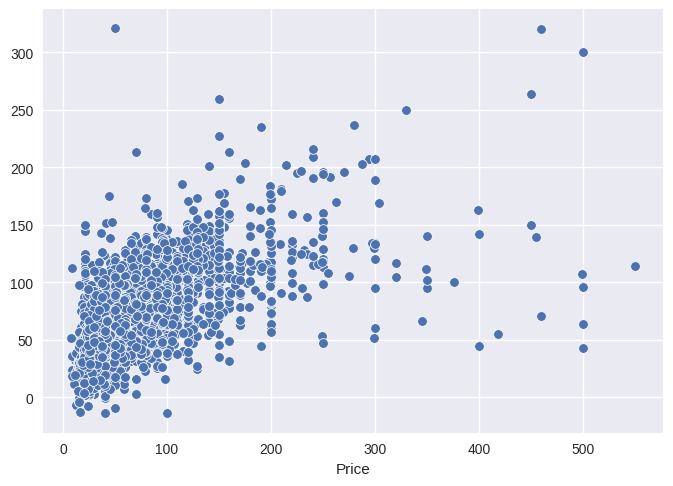

In [55]:
sns.scatterplot(x=y_val, y=y_val_pred_LR)

### *Decision Tree Regressor*

In [102]:
model_DTR = DecisionTreeRegressor(random_state=42)
model_DTR.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [103]:
# make predictions on the validation set
y_val_pred_DTR = model_DTR.predict(X_val)

In [104]:
regressionMetrics(y_val, y_val_pred_DTR)

{'MAE': 27.120204603580564,
 'MSE': 2497.236146632566,
 'RMSE': np.float64(49.97235382321475),
 'RMSLE': np.float64(0.5480483591644228),
 'R²': -0.046057825541242714}

In [105]:
model_dict = {"model":"DecisionTree"}
model_dict.update(regressionMetrics(y_val, y_val_pred_DTR))
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)
# models_list.style.set_properties(**{'text-align': 'left'})
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058


<Axes: xlabel='Price'>

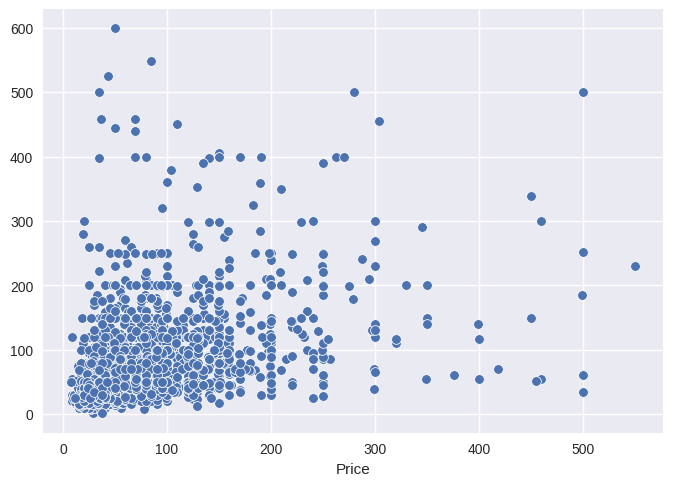

In [106]:
sns.scatterplot(x=y_val, y=y_val_pred_DTR)

### RandomForestRegressor

In [107]:
model_RFR = RandomForestRegressor(random_state=42)
model_RFR.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [108]:
# Make predictions on the validation set
y_val_pred_RFR = model_RFR.predict(X_val)

In [109]:
regressionMetrics(y_val, y_val_pred_RFR)

{'MAE': 19.829559782608698,
 'MSE': 1181.851733557598,
 'RMSE': np.float64(34.378070532791654),
 'RMSLE': np.float64(0.4086207077802105),
 'R²': 0.5049385873320408}

In [110]:
model_dict = {'model': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_RFR)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939


<Axes: xlabel='Price'>

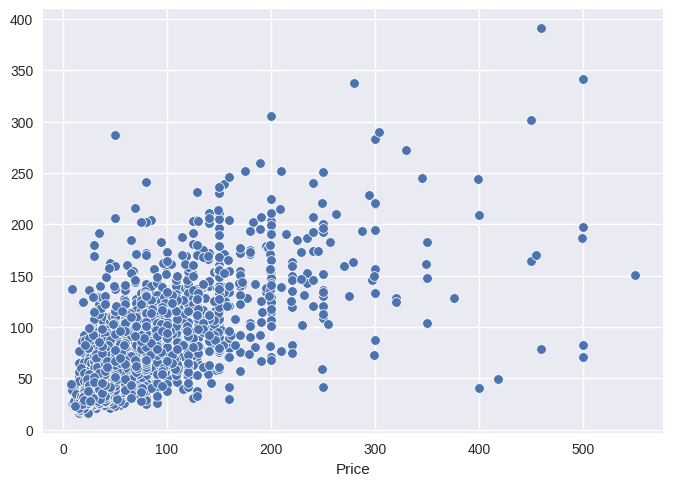

In [111]:
sns.scatterplot(x=y_val, y=y_val_pred_RFR)

### Adaptive Boosting (ADABoost)

In [112]:
model_ADABoost = AdaBoostRegressor(random_state=42)
model_ADABoost.fit(X_train, y_train)

AdaBoostRegressor(random_state=42)

In [113]:
# Make predictions on the validation set
y_val_pred_ADABoost = model_ADABoost.predict(X_val)

In [114]:
regressionMetrics(y_val, y_val_pred_ADABoost)

{'MAE': 30.27385712514753,
 'MSE': 2096.914683742509,
 'RMSE': np.float64(45.792081015635326),
 'RMSLE': np.float64(0.5667969789098966),
 'R²': 0.1216313213393776}

Update model list with **Adaptive Boosting (ADABoost)** model results

In [115]:
model_dict = {'model': "ADABoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_ADABoost)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939
3,ADABoost,30.273857,2096.914684,45.792081,0.566797,0.121631


<Axes: xlabel='Price'>

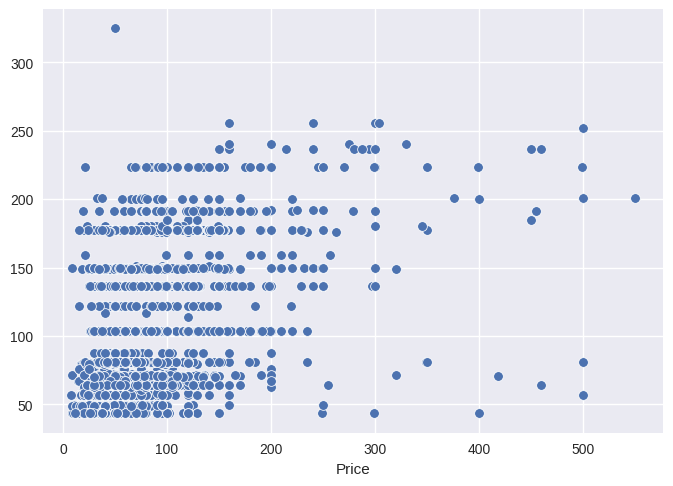

In [116]:
sns.scatterplot(x=y_val, y=y_val_pred_ADABoost)

### Gradient Boosting Machine (GBM)

In [117]:
model_GBM = GradientBoostingRegressor(random_state=42)
model_GBM.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [118]:
# Make predictions on the validation set
y_val_pred_GBM = model_GBM.predict(X_val)

In [119]:
model_dict = {'model': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_GBM)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939
3,ADABoost,30.273857,2096.914684,45.792081,0.566797,0.121631
4,GBM,19.379332,1120.280692,33.470594,0.400346,0.530730


<Axes: xlabel='Price'>

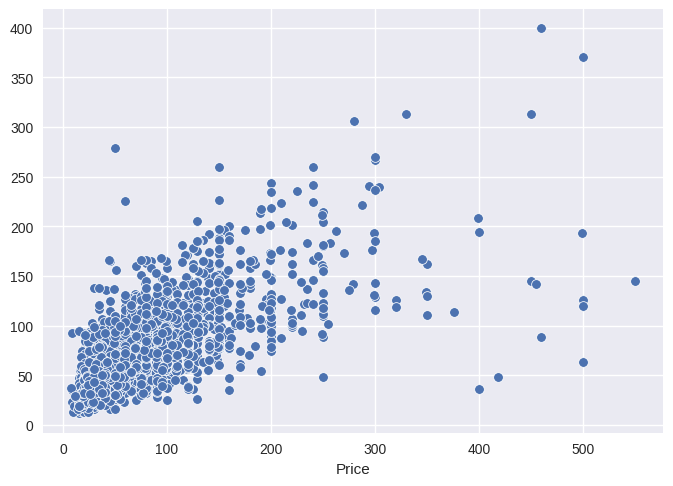

In [121]:
sns.scatterplot(x=y_val, y=y_val_pred_GBM)

### Support Vector Machine (SVM)

In [122]:
model_SVR = SVR()
model_SVR.fit(X_train, y_train)

SVR()

In [126]:
# Make predictions on the validation set
y_val_pred_SVR = model_SVR.predict(X_val)

In [127]:
regressionMetrics(y_val,y_val_pred_SVR)

{'MAE': 27.621772879222128,
 'MSE': 2395.0111715286353,
 'RMSE': np.float64(48.93885135072783),
 'RMSLE': np.float64(0.5614632080818162),
 'R²': -0.0032371914905056087}

In [128]:
model_dict = {'model': "SVM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val,y_val_pred_SVR)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939
3,ADABoost,30.273857,2096.914684,45.792081,0.566797,0.121631
4,GBM,19.379332,1120.280692,33.470594,0.400346,0.530730
5,XGBoost,18.744146,1020.410330,31.943862,0.391512,0.572564
6,SVM,27.621773,2395.011172,48.938851,0.561463,-0.003237


<Axes: xlabel='Price'>

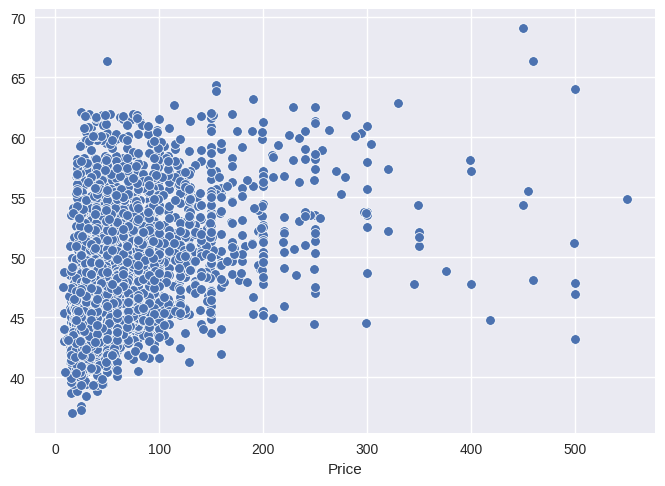

In [75]:
sns.scatterplot(x=y_val, y=y_val_pred_SVR)

### XGBoost Regressor

In [123]:
model_XGBoost= xgb.XGBRegressor()
model_XGBoost.fit(X_train, y_train)
# Make predictions on the validation set
y_val_pred_XGBoost = model_XGBoost.predict(X_val)

In [124]:
regressionMetrics(y_val,y_val_pred_XGBoost)

{'MAE': 18.744145969499,
 'MSE': 1020.4103298543131,
 'RMSE': np.float64(31.943862162461087),
 'RMSLE': np.float64(0.391512126210969),
 'R²': 0.5725641676913147}

In [125]:
model_dict = {'model': "XGBoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val,y_val_pred_XGBoost)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939
3,ADABoost,30.273857,2096.914684,45.792081,0.566797,0.121631
4,GBM,19.379332,1120.280692,33.470594,0.400346,0.530730
5,XGBoost,18.744146,1020.410330,31.943862,0.391512,0.572564


<Axes: xlabel='Price'>

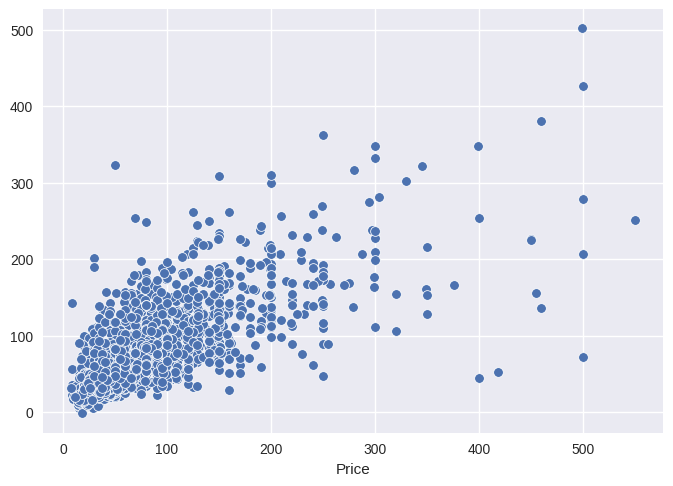

In [79]:
sns.scatterplot(x=y_val, y=y_val_pred_XGBoost)

Metrics:<br><b>MSE</b> - Mean Squared Error<br><b>RMSE</b> Root Mean Squared Error<br><b>MAE </b>Mean Absolute Error Calculates the average of the absolute differences between predicted and actual values.<br>
<b>RMSLE</b> Root Mean Squared Logarithmic Error

In [129]:
models_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
5,XGBoost,18.744146,1020.410330,31.943862,0.391512,0.572564
4,GBM,19.379332,1120.280692,33.470594,0.400346,0.530730
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
6,SVM,27.621773,2395.011172,48.938851,0.561463,-0.003237
3,ADABoost,30.273857,2096.914684,45.792081,0.566797,0.121631


# Hyperparameters and Finetuning

In [130]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

### Random Search: we decide which parameters and how (randomly)

In [163]:
# Reduced number of options for each hyperparameter
n_estimators = [100, 200, 300]  # Fewer values for the number of trees
max_features = ['auto','sqrt']  #  # Number of features to consider at each split
max_depth = [10, 20, 30, 40, None]  # Fewer values for max depth
min_samples_split = [2, 5, 10]  # Keep essential options only
min_samples_leaf = [1, 2, 4]  # Reduced options for leaf samples
bootstrap = [True, False]  # Keep as is

# Create a lighter random grid
lighter_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}

print(lighter_grid)

# Reduced number of iterations and cross-validation folds
# rf_random = RandomizedSearchCV(estimator=model_GBM, param_distributions=lighter_grid, n_iter=25, cv=3,
#                                verbose=2, random_state=42, n_jobs=-1)
rf_random = RandomizedSearchCV(estimator=model_RFR, param_distributions=lighter_grid, n_iter=25, cv=3,
                               verbose=2, random_state=42, n_jobs=-1)

# Fit the random search model
rf_random.fit(X_train, y_train)

{'n_estimators': [100, 200, 300], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=2)

In [164]:
rf_random.best_estimator_

GradientBoostingRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=2,
                          min_samples_split=10, random_state=42)

In [132]:
def evaluate(model, test_features, y_test):
    predictions = model.predict(test_features)
    errors = abs(predictions - y_test)
    mae = 100 * np.mean(errors)
    print('Model Performance')
    print('Mean Absolute Error: {:0.4f}'.format(np.mean(errors)))
    # print('R^2: {:0.2f}'.format(metrics.r2_score(predictions, y_test)))
    return mae

#### Running base Model

In [136]:
base_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_val, y_val)

Model Performance
Mean Absolute Error: 19.8296


In [166]:
best_random = rf_random.best_estimator_
random_accuracy = evaluate(best_random, X_val, y_val)

Model Performance
Mean Absolute Error: 18.3416


#### Comparisson

In [138]:
print('Improvement of {:0.2f}%.'.format( 100 * (base_accuracy - random_accuracy) / base_accuracy))

Improvement of 6.30%.


Good improvment from the finetunuing when used with **RandomForestRegressor**, so we can try use the tinued model instead of basic

After we added the tuned Random Forest Regressor to all metrics table , we can see it is a little better from XGBoost Model

# Model Evaluation

## Performance Metrics:

In [88]:
# make predictions on the validation set
y_val_pred_RFR_best_random = best_random.predict(X_val)

In [134]:
model_dict = {"model":"DecisionTree_Tuned"}
model_dict.update(regressionMetrics(y_val, y_val_pred_RFR_best_random))
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939
3,ADABoost,30.273857,2096.914684,45.792081,0.566797,0.121631
4,GBM,19.379332,1120.280692,33.470594,0.400346,0.530730
5,XGBoost,18.744146,1020.410330,31.943862,0.391512,0.572564
6,SVM,27.621773,2395.011172,48.938851,0.561463,-0.003237
7,DecisionTree_Tuned,18.579837,1051.757888,32.430817,0.387561,0.559433


In [135]:
models_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
7,DecisionTree_Tuned,18.579837,1051.757888,32.430817,0.387561,0.559433
5,XGBoost,18.744146,1020.410330,31.943862,0.391512,0.572564
4,GBM,19.379332,1120.280692,33.470594,0.400346,0.530730
2,RandomForest,19.829560,1181.851734,34.378071,0.408621,0.504939
0,LinearRegression,21.961631,1401.315646,37.434151,0.478846,0.413008
1,DecisionTree,27.120205,2497.236147,49.972354,0.548048,-0.046058
6,SVM,27.621773,2395.011172,48.938851,0.561463,-0.003237
3,ADABoost,30.273857,2096.914684,45.792081,0.566797,0.121631


## Validation:

In [158]:
models_ = {"LinearRegression":model_LR,
           "DecisionTree":model_DTR,
           "RandomForest":model_RFR,
           "ADABoost":model_ADABoost,
           "GBM":model_GBM,
           "SVR":model_SVR,
           "XGBoost":model_XGBoost,
           "RandomForest_Tuned":best_random
           }
models_eval_list = pd.DataFrame(columns= ['model', 'MAE', 'MSE', 'RMSE', 'RMSLE', 'R²'])

In [159]:
for name, model in models_.items():
    print(model)
    y_test_pred = model.predict(X_test)
    # print(regressionMetrics(y_test, y_test_pred))
    model_dict = {"model":name}
    model_dict.update(regressionMetrics(y_test, y_test_pred))
    new_row = pd.DataFrame([model_dict])
    models_eval_list = pd.concat([models_eval_list, new_row], ignore_index=True)

LinearRegression()
DecisionTreeRegressor(random_state=42)
RandomForestRegressor(random_state=42)
AdaBoostRegressor(random_state=42)
GradientBoostingRegressor(random_state=42)
SVR()
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)
RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt'

In [160]:
models_eval_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.619280,1318.622802,36.312846,0.463545,0.414680
1,DecisionTree,26.652387,2395.104646,48.939806,0.541648,-0.063157
2,RandomForest,19.610050,1130.048774,33.616198,0.404550,0.498386
3,ADABoost,29.402609,1986.161338,44.566370,0.551963,0.118368
4,GBM,19.249985,1078.107051,32.834541,0.394858,0.521442
5,SVR,27.280935,2265.220262,47.594330,0.554537,-0.005503
6,XGBoost,18.640150,1013.195768,31.830736,0.388265,0.550255
7,RandomForest_Tuned,18.482913,1006.249004,31.721428,0.384012,0.553339


In [161]:
models_eval_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
7,RandomForest_Tuned,18.482913,1006.249004,31.721428,0.384012,0.553339
6,XGBoost,18.640150,1013.195768,31.830736,0.388265,0.550255
4,GBM,19.249985,1078.107051,32.834541,0.394858,0.521442
2,RandomForest,19.610050,1130.048774,33.616198,0.404550,0.498386
0,LinearRegression,21.619280,1318.622802,36.312846,0.463545,0.414680
1,DecisionTree,26.652387,2395.104646,48.939806,0.541648,-0.063157
5,SVR,27.280935,2265.220262,47.594330,0.554537,-0.005503
3,ADABoost,29.402609,1986.161338,44.566370,0.551963,0.118368


# Save Model and dataframe objects

In [94]:
import joblib

joblib.dump(model_LR,"/content/drive/My Drive/Airbnb/model_LR.pkl")
joblib.dump(model_DTR,"/content/drive/My Drive/Airbnb/model_DTR.pkl")
joblib.dump(model_RFR,"/content/drive/My Drive/Airbnb/model_RFR.pkl")
joblib.dump(model_ADABoost,"/content/drive/My Drive/Airbnb/model_ADABoost.pkl")
joblib.dump(model_GBM,"/content/drive/My Drive/Airbnb/model_GBM.pkl")
joblib.dump(model_SVR,"/content/drive/My Drive/Airbnb/model_SVR.pkl")
joblib.dump(model_XGBoost,"/content/drive/My Drive/Airbnb/model_XGBoost.pkl")
joblib.dump(best_random,"/content/drive/My Drive/Airbnb/best_random.pkl")

models_list.to_pickle("/content/drive/My Drive/Airbnb/models_selection_list.pkl")
df.to_pickle("/content/drive/My Drive/Airbnb/df_Model_Selection_Post.pkl")

In [95]:
# model_LR_ = joblib.load("/content/drive/My Drive/Airbnb/model_LR.pkl")